In [1]:
import os
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rc("svg", fonttype="none")
sns.set(context="talk", style="ticks")

from lib.utils.plot_utils import get_id

In [2]:
# Plot color
cols1 = sns.color_palette("Greys", 2)
cols2 = sns.color_palette("Oranges", 2)
cols3 = sns.color_palette("Blues", 2)

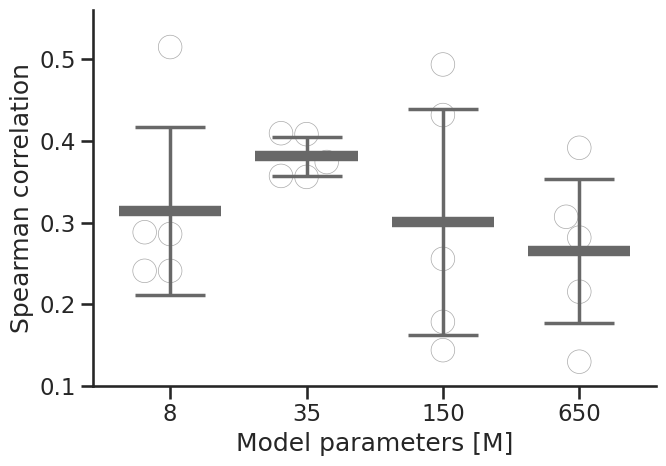

In [3]:
# Prediciton scores of pretrained ESM2
scores = pd.read_csv("./tables/scores_ridge.csv")
scores_pretrained = scores[scores.db_size == "-"]
scores_pretrained.insert(1, "x", scores_pretrained.plm_size.apply(get_id))


# Plot
fig, ax = plt.subplots(figsize=(7, 5))
sns.swarmplot(
    ax=ax,
    data=scores_pretrained,
    x="plm_size",
    y="spearmanr",
    hue="plm_size",
    s=17,
    palette=["none", "none", "none", "none"],
    edgecolor="darkgray",
    linewidth=0.5,
    zorder=1,
    legend=None
)
sns.boxplot(
    showmeans=True,
    ax=ax,
    meanline=True,
    meanprops={'color': cols1[1], 'ls': '-', 'lw': 7.5},
    medianprops={'visible': False},
    whiskerprops={'visible': False},
    data=scores_pretrained,
    x="plm_size",
    y="spearmanr",
    showfliers=False,
    showbox=False,
    showcaps=False,
    width=0.75,
    zorder=2
)
for i in range(4):
    vals = scores_pretrained[scores_pretrained.x == i].spearmanr.values
    ax.errorbar(
        i,
        np.mean(vals),
        np.std(vals),
        lw=2.5,
        capthick=2.5,
        capsize=25,
        color=cols1[1],
        zorder=2
    )
ax.set_ylim(0.1, 0.56)
ax.set_xlabel("Model parameters [M]")
ax.set_ylabel("Spearman correlation")
ax.set_xticks(range(4), ["8", "35", "150", "650"])
ax.set_yticks(np.arange(0.1, 0.55, 0.1))
sns.despine()
fig.tight_layout()
fig.savefig("./figures/spearmanr_ridge_pretrained.svg")